# Predictive Modeling and Risk Scoring for Bank Customer Churn

## Notebook 1: Exploratory Data Analysis (EDA)

### Objective
This notebook performs Exploratory Data Analysis on the bank customer churn dataset.

The analysis focuses on:
- Understanding the dataset structure
- Identifying missing values and duplicate records
- Understanding numerical and categorical variables
- Analyzing the target variable `Exited`
- Measuring the overall churn rate
- Studying churn patterns across customer characteristics
- Detecting outliers
- Analyzing relationships between variables
- Identifying potential churn drivers for later modeling

The target variable is:

`Exited`
- 0 → Customer retained
- 1 → Customer churned

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("European_Bank.csv")

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 10,000
Columns : 14


In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
rows, columns = df.shape

print(f"Number of rows    : {rows:,}")
print(f"Number of columns : {columns}")

Number of rows    : 10,000
Number of columns : 14


In [6]:
print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Year
2. CustomerId
3. Surname
4. CreditScore
5. Geography
6. Gender
7. Age
8. Tenure
9. Balance
10. NumOfProducts
11. HasCrCard
12. IsActiveMember
13. EstimatedSalary
14. Exited


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Year', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Categorical Columns:
['Surname', 'Geography', 'Gender']


In [9]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_values = missing_values.sort_values(
    by="Missing Count",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
Year,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [10]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 0


In [11]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_values

,Column,Unique Values
0,Year,1
1,CustomerId,10000
2,Surname,2932
3,CreditScore,460
4,Geography,3
5,Gender,2
6,Age,70
7,Tenure,11
8,Balance,6382
9,NumOfProducts,4


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [13]:
df.describe(include="object").T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [14]:
target_counts = df["Exited"].value_counts().sort_index()

print("Target Distribution:")
print(target_counts)

print("\nTarget Percentages:")
print((df["Exited"].value_counts(normalize=True) * 100).sort_index())

Target Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Target Percentages:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


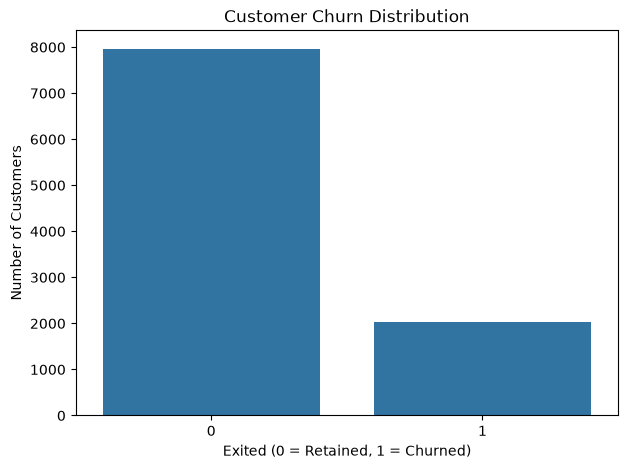

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
churn_rate = df["Exited"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")
print(f"Retention rate: {100 - churn_rate:.2f}%")

Overall churn rate: 20.37%
Retention rate: 79.63%


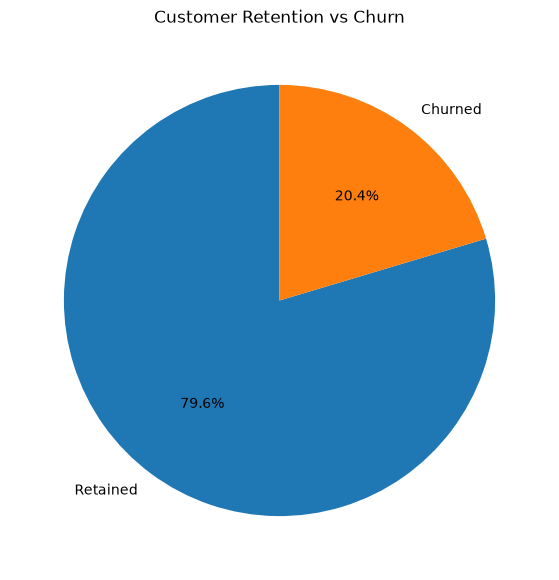

In [17]:
labels = ["Retained", "Churned"]
values = [
    (df["Exited"] == 0).sum(),
    (df["Exited"] == 1).sum()
]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Retention vs Churn")

plt.show()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


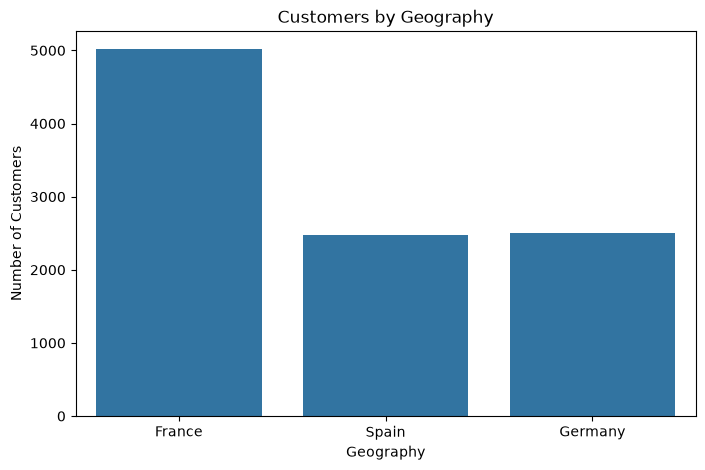

In [18]:
print(df["Geography"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Geography"
)

plt.title("Customers by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.show()

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64


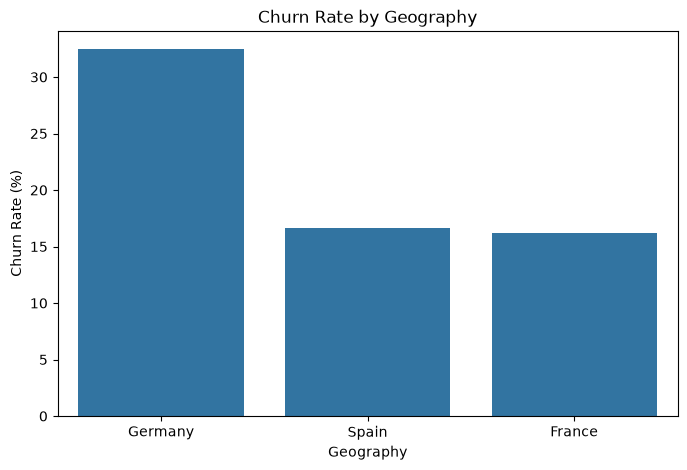

In [19]:
geography_churn = (
    df.groupby("Geography")["Exited"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(geography_churn)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=geography_churn.index,
    y=geography_churn.values
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

Gender
Male      5457
Female    4543
Name: count, dtype: int64


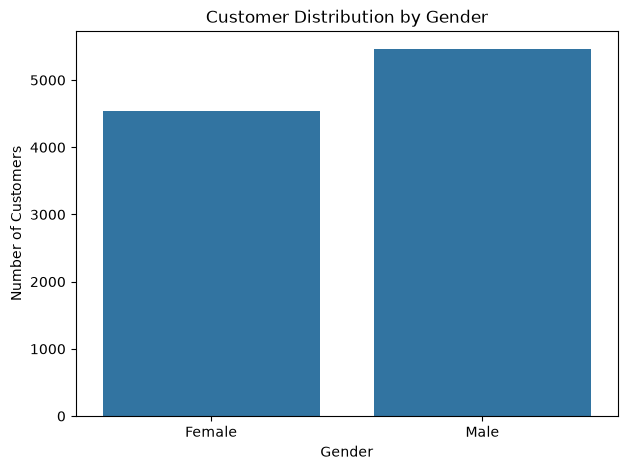

In [20]:
print(df["Gender"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


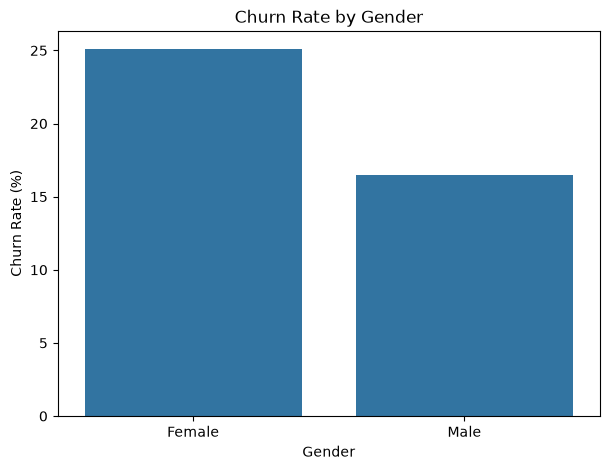

In [21]:
gender_churn = (
    df.groupby("Gender")["Exited"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(gender_churn)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

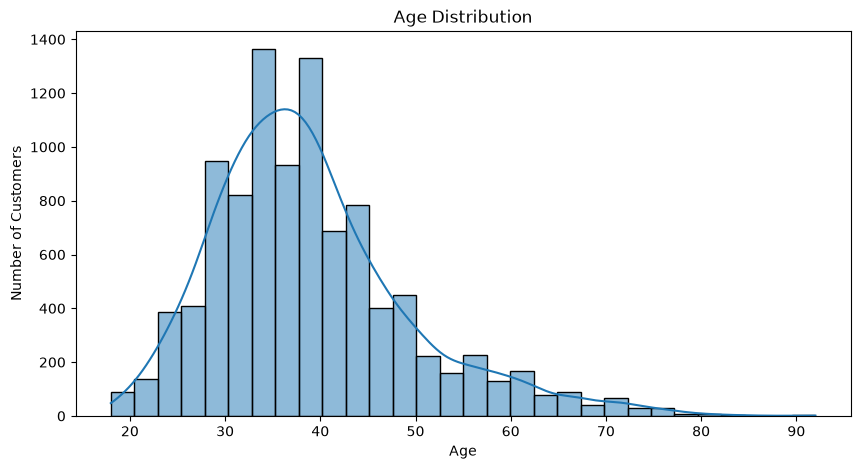

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

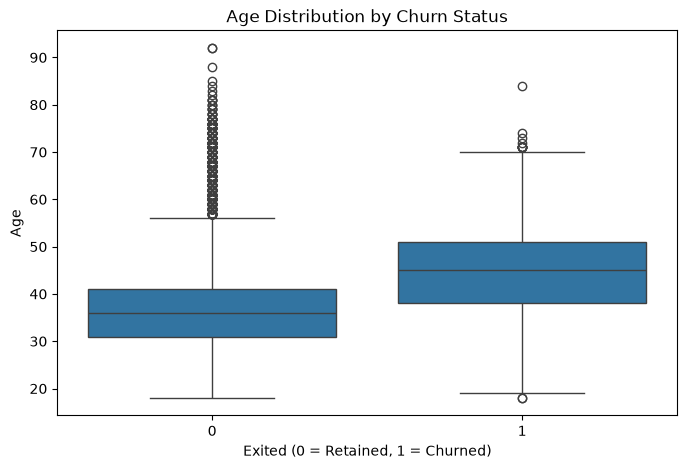

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Age")

plt.show()

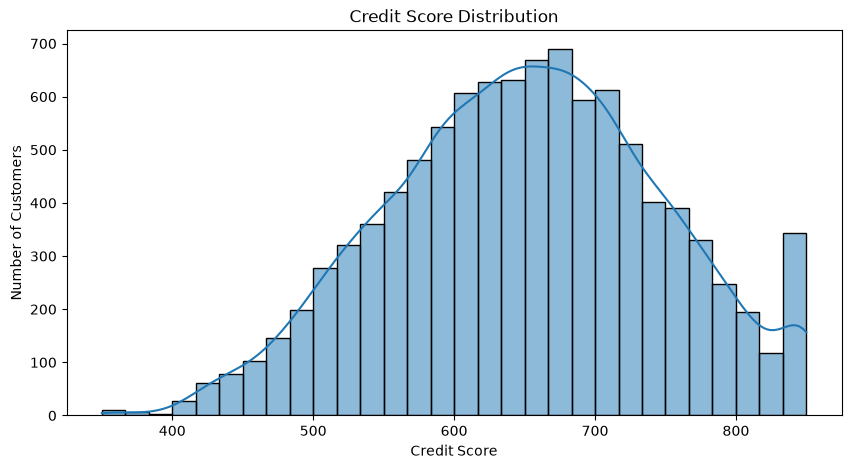

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="CreditScore",
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

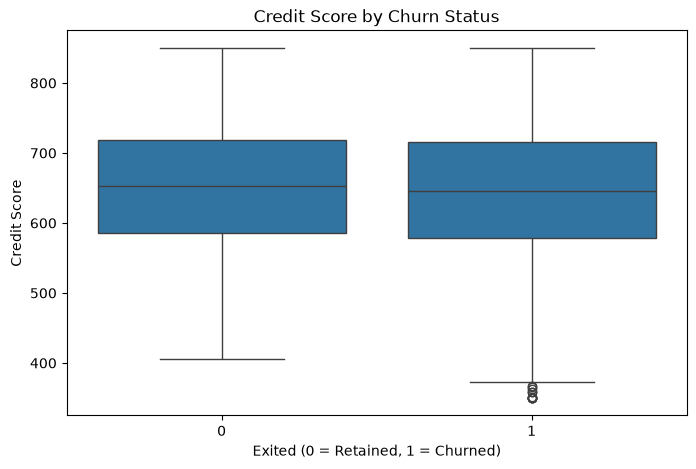

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score by Churn Status")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Credit Score")

plt.show()

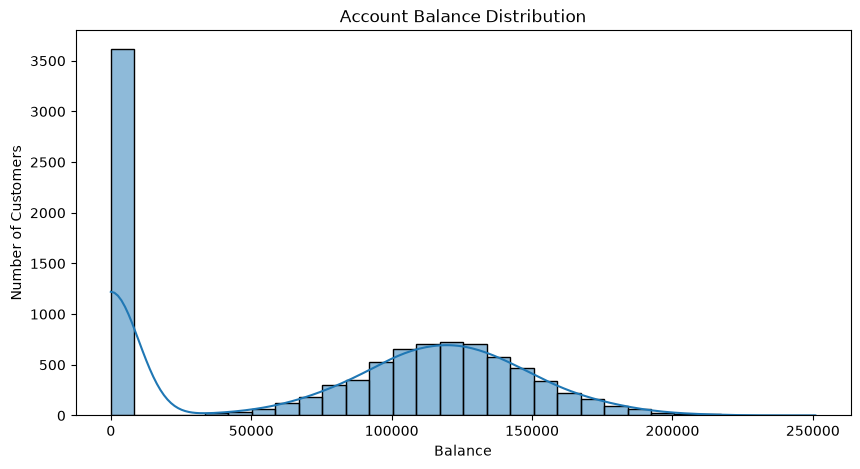

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Balance",
    bins=30,
    kde=True
)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()

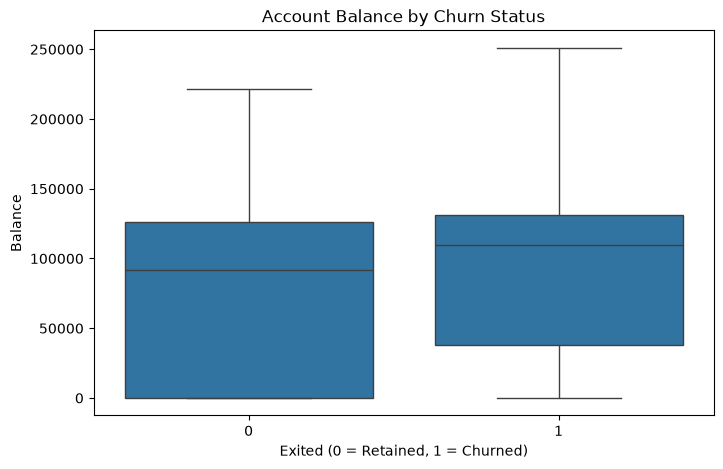

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance"
)

plt.title("Account Balance by Churn Status")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Balance")

plt.show()

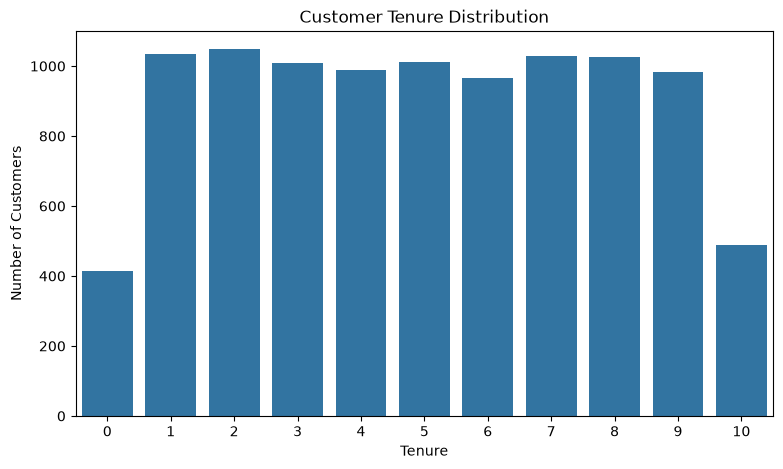

In [28]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Tenure"
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.show()

Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64


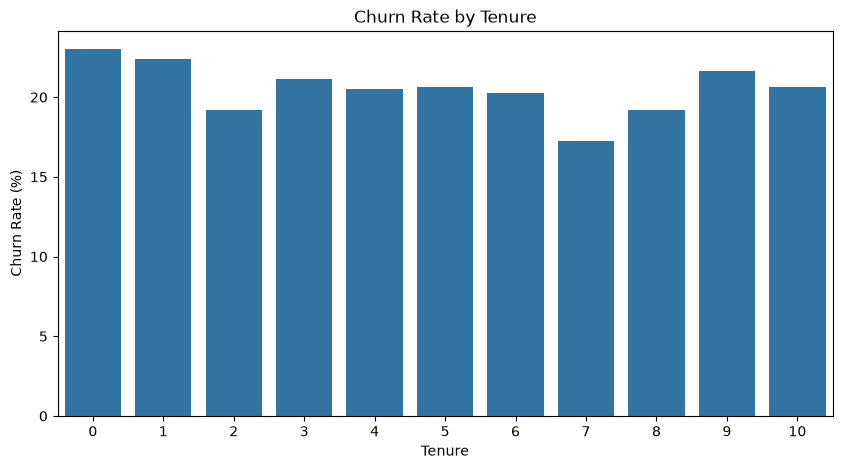

In [29]:
tenure_churn = (
    df.groupby("Tenure")["Exited"]
    .mean()
    * 100
)

print(tenure_churn)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


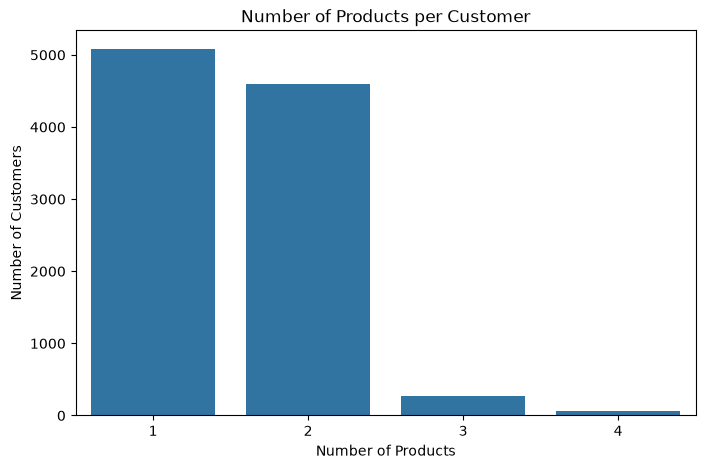

In [30]:
print(df["NumOfProducts"].value_counts().sort_index())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="NumOfProducts"
)

plt.title("Number of Products per Customer")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


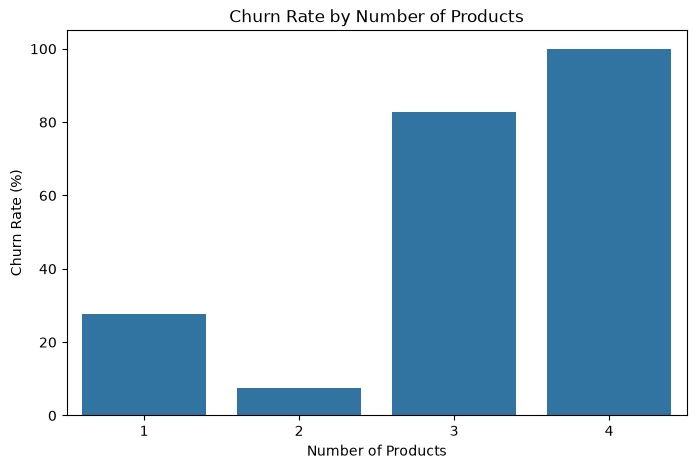

In [31]:
product_churn = (
    df.groupby("NumOfProducts")["Exited"]
    .mean()
    * 100
)

print(product_churn)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=product_churn.index,
    y=product_churn.values
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


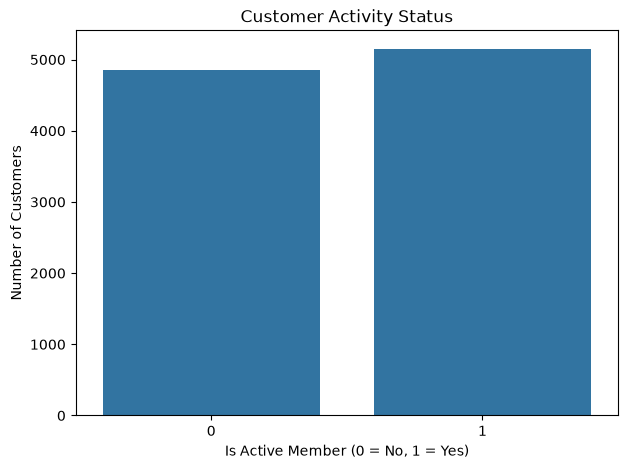

In [32]:
print(df["IsActiveMember"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="IsActiveMember"
)

plt.title("Customer Activity Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


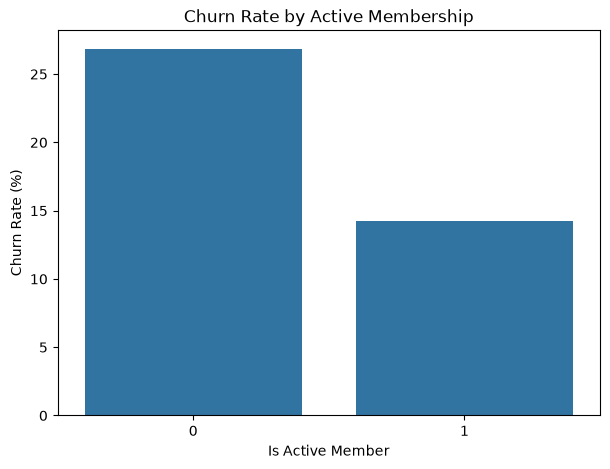

In [33]:
activity_churn = (
    df.groupby("IsActiveMember")["Exited"]
    .mean()
    * 100
)

print(activity_churn)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=activity_churn.index,
    y=activity_churn.values
)

plt.title("Churn Rate by Active Membership")
plt.xlabel("Is Active Member")
plt.ylabel("Churn Rate (%)")

plt.show()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64


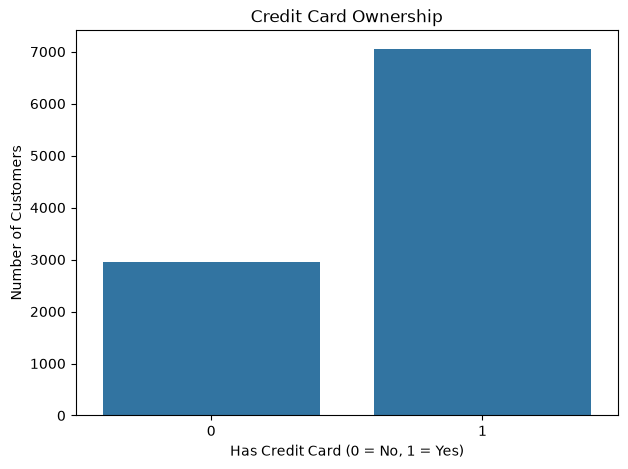

In [34]:
print(df["HasCrCard"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="HasCrCard"
)

plt.title("Credit Card Ownership")
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


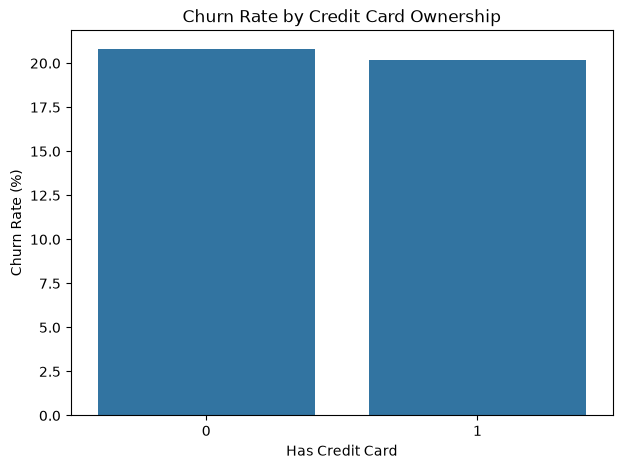

In [35]:
credit_card_churn = (
    df.groupby("HasCrCard")["Exited"]
    .mean()
    * 100
)

print(credit_card_churn)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=credit_card_churn.index,
    y=credit_card_churn.values
)

plt.title("Churn Rate by Credit Card Ownership")
plt.xlabel("Has Credit Card")
plt.ylabel("Churn Rate (%)")

plt.show()

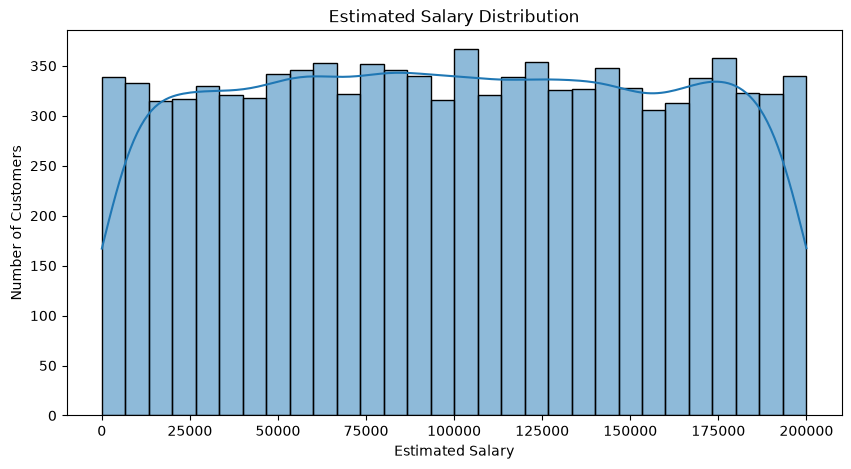

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="EstimatedSalary",
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.show()

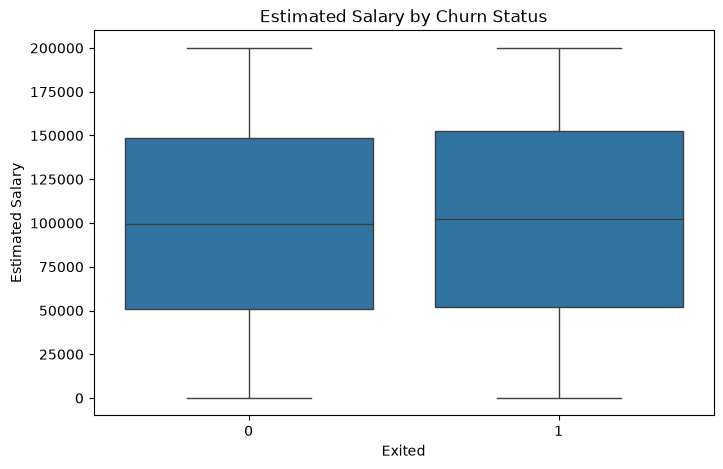

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="EstimatedSalary"
)

plt.title("Estimated Salary by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Estimated Salary")

plt.show()

## Outlier Analysis

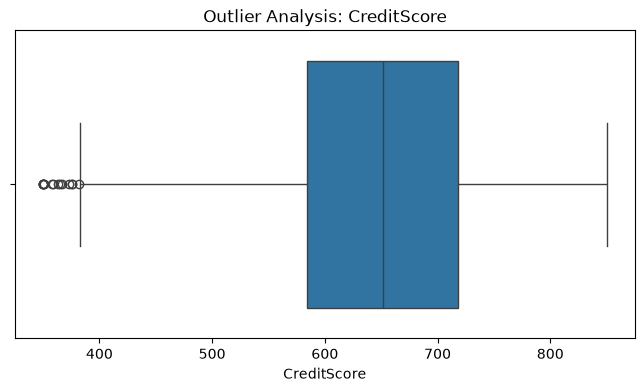

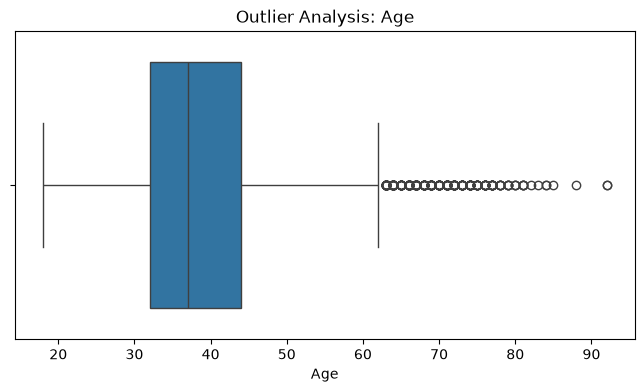

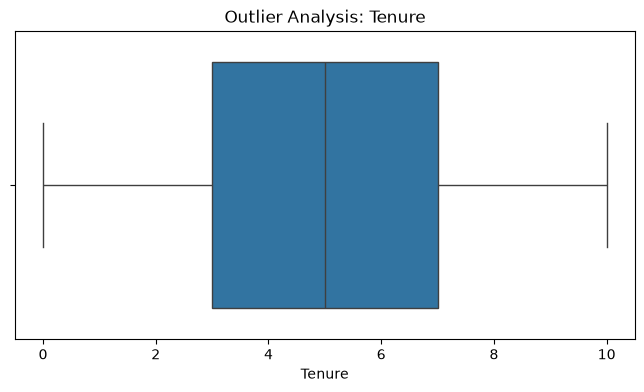

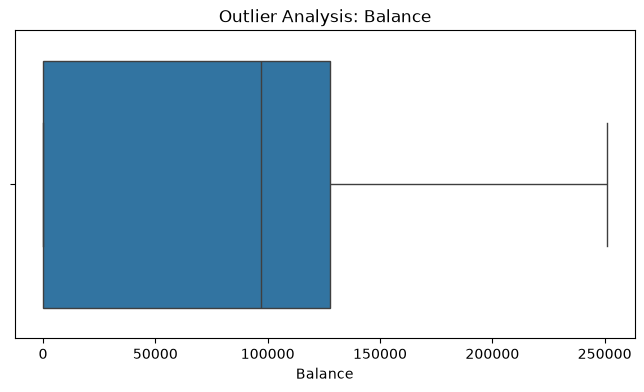

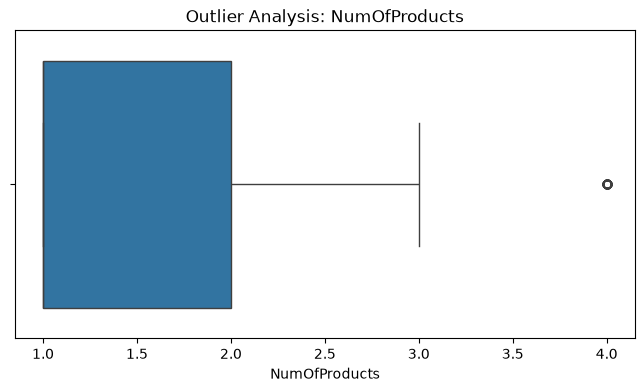

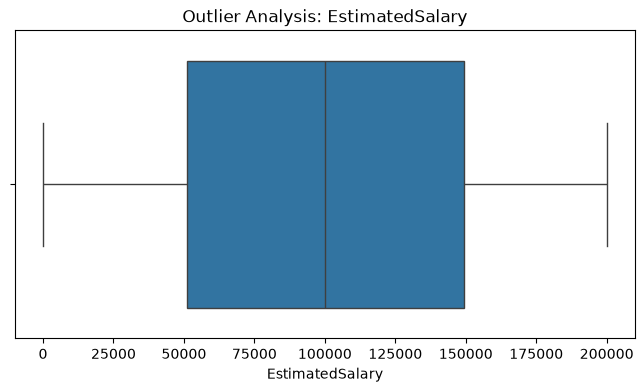

In [38]:
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for column in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Outlier Analysis: {column}")
    plt.xlabel(column)

    plt.show()

In [39]:
outlier_summary = []

for column in numerical_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15,0.15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359,3.59
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0,0.00
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0,0.00
4,NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60,0.60
5,EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0,0.00


## Correlation Analysis

In [40]:
correlation_matrix = df[numerical_features + ["Exited"]].corr()

correlation_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204,-0.047820
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,0.012097,1.000000


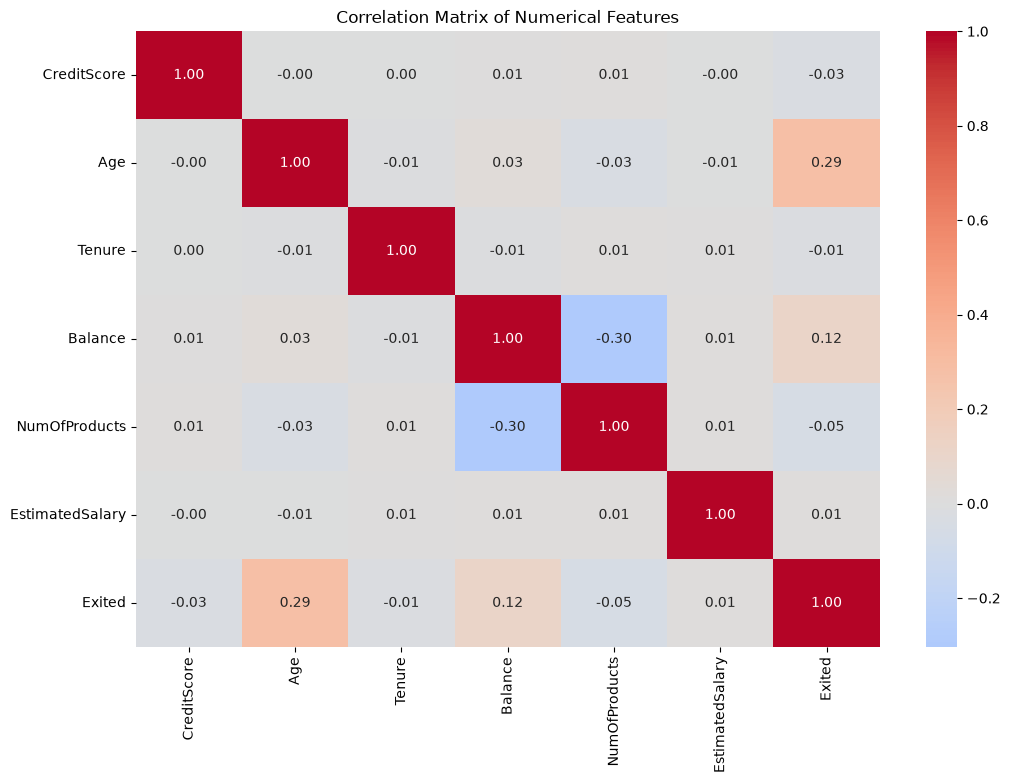

In [41]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [42]:
target_correlation = (
    correlation_matrix["Exited"]
    .drop("Exited")
    .sort_values(key=abs, ascending=False)
)

print("Correlation of Numerical Features with Churn:")
print(target_correlation)

Correlation of Numerical Features with Churn:
Age                0.285323
Balance            0.118533
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
EstimatedSalary    0.012097
Name: Exited, dtype: float64


## Churn analysis

In [43]:
categorical_analysis = {}

for column in ["Geography", "Gender", "Tenure", "NumOfProducts",
               "HasCrCard", "IsActiveMember"]:

    categorical_analysis[column] = (
        df.groupby(column)["Exited"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Customer Count",
            "mean": "Churn Rate"
        })
    )

    categorical_analysis[column]["Churn Rate"] *= 100

categorical_analysis

{'Geography':            Customer Count  Churn Rate
 Geography                            
 France               5014   16.154767
 Germany              2509   32.443204
 Spain                2477   16.673395,
 'Gender':         Customer Count  Churn Rate
 Gender                            
 Female            4543   25.071539
 Male              5457   16.455928,
 'Tenure':         Customer Count  Churn Rate
 Tenure                            
 0                  413   23.002421
 1                 1035   22.415459
 2                 1048   19.179389
 3                 1009   21.110010
 4                  989   20.525784
 5                 1012   20.652174
 6                  967   20.268873
 7                 1028   17.217899
 8                 1025   19.219512
 9                  984   21.646341
 10                 490   20.612245,
 'NumOfProducts':                Customer Count  Churn Rate
 NumOfProducts                            
 1                        5084   27.714398
 2         

AgeGroup_EDA
Under 30     7.520325
30-40       12.087171
40-50       33.965517
50-60       56.210790
60+         24.784483
Name: Exited, dtype: float64


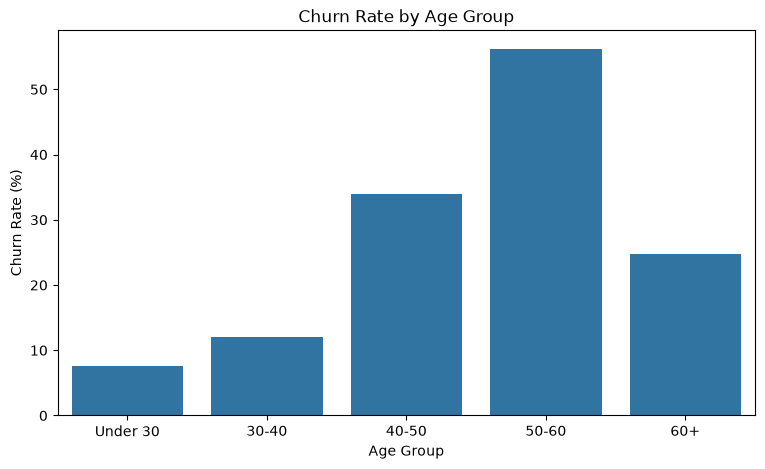

In [44]:
df["AgeGroup_EDA"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["Under 30", "30-40", "40-50", "50-60", "60+"]
)

age_group_churn = (
    df.groupby("AgeGroup_EDA", observed=True)["Exited"]
    .mean()
    * 100
)

print(age_group_churn)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_group_churn.index,
    y=age_group_churn.values
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [45]:
geo_activity_churn = (
    df.groupby(["Geography", "IsActiveMember"])["Exited"]
    .mean()
    .reset_index()
)

geo_activity_churn["Exited"] *= 100

geo_activity_churn

,Geography,IsActiveMember,Exited
0,France,0,21.130830
1,France,1,11.501351
2,Germany,0,41.078509
3,Germany,1,23.717949
4,Spain,0,23.347639
5,Spain,1,10.746951


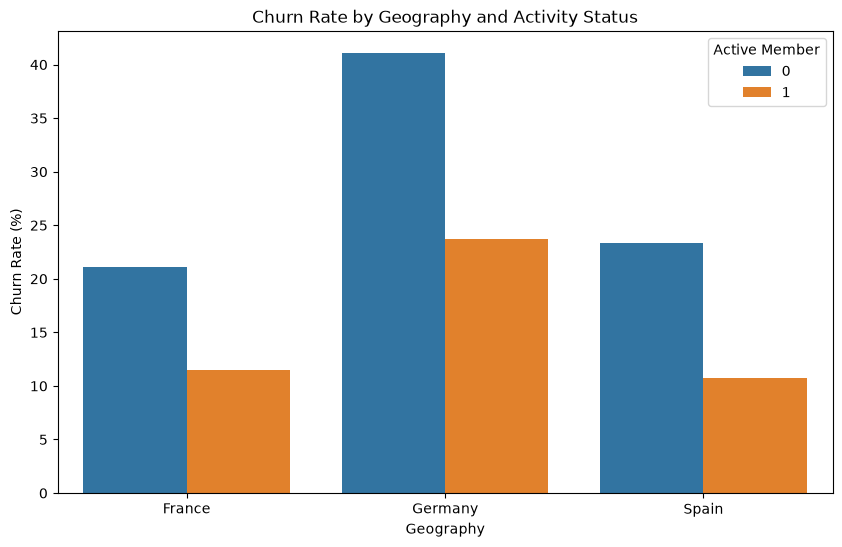

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=geo_activity_churn,
    x="Geography",
    y="Exited",
    hue="IsActiveMember"
)

plt.title("Churn Rate by Geography and Activity Status")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Active Member")

plt.show()

In [47]:
geo_product_churn = (
    df.groupby(["Geography", "NumOfProducts"])["Exited"]
    .mean()
    .reset_index()
)

geo_product_churn["Exited"] *= 100

geo_product_churn

,Geography,NumOfProducts,Exited
0,France,1,22.434368
1,France,2,5.703422
2,France,3,78.846154
3,France,4,100.000000
4,Germany,1,42.846553
5,Germany,2,12.115385
6,Germany,3,89.583333
7,Germany,4,100.000000
8,Spain,1,21.867322
9,Spain,2,7.354184


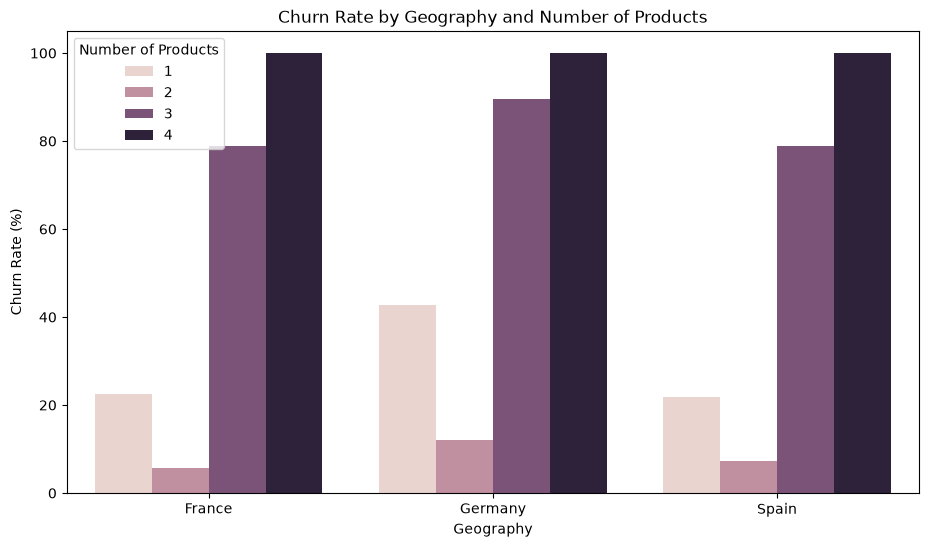

In [48]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=geo_product_churn,
    x="Geography",
    y="Exited",
    hue="NumOfProducts"
)

plt.title("Churn Rate by Geography and Number of Products")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Number of Products")

plt.show()

In [49]:
comparison_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

customer_comparison = (
    df.groupby("Exited")[comparison_features]
    .mean()
    .T
)

customer_comparison.columns = [
    "Retained Customers",
    "Churned Customers"
]

customer_comparison

,Retained Customers,Churned Customers
CreditScore,651.853196,645.351497
Age,37.408389,44.837997
Tenure,5.033279,4.932744
Balance,72745.296779,91108.539337
NumOfProducts,1.544267,1.475209
EstimatedSalary,99738.391772,101465.677531


In [50]:
median_comparison = (
    df.groupby("Exited")[comparison_features]
    .median()
    .T
)

median_comparison.columns = [
    "Retained Customers",
    "Churned Customers"
]

median_comparison

,Retained Customers,Churned Customers
CreditScore,653.00,646.00
Age,36.00,45.00
Tenure,5.00,5.00
Balance,92072.68,109349.29
NumOfProducts,2.00,1.00
EstimatedSalary,99645.04,102460.84


In [51]:
churn_summary = pd.DataFrame({
    "Feature": [
        "Geography",
        "Gender",
        "Age",
        "Tenure",
        "Balance",
        "Number of Products",
        "Credit Card",
        "Active Membership",
        "Estimated Salary",
        "Credit Score"
    ]
})

churn_summary

,Feature
0,Geography
1,Gender
2,Age
3,Tenure
4,Balance
5,Number of Products
6,Credit Card
7,Active Membership
8,Estimated Salary
9,Credit Score


In [52]:
summary = {
    "Total Customers": len(df),
    "Total Features": df.shape[1] - 1,
    "Churned Customers": int(df["Exited"].sum()),
    "Retained Customers": int((df["Exited"] == 0).sum()),
    "Churn Rate (%)": round(df["Exited"].mean() * 100, 2),
    "Missing Values": int(df.isnull().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum())
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Customers,10000.00
1,Total Features,14.00
2,Churned Customers,2037.00
3,Retained Customers,7963.00
4,Churn Rate (%),20.37
5,Missing Values,0.00
6,Duplicate Rows,0.00


## EDA Conclusions

The exploratory analysis provides the following observations:

1. The dataset contains customer-level banking information along with the churn target `Exited`.

2. `CustomerId` and `Surname` are identifiers and are not expected to provide useful predictive information. They will therefore be excluded during preprocessing.

3. `Geography` and `Gender` are categorical variables that require encoding before machine learning.

4. Numerical variables such as `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, and `EstimatedSalary` have different scales and will require appropriate preprocessing.

5. The target variable `Exited` should be examined for class imbalance before model training.

6. Churn rates vary across customer groups. These differences will be investigated further using machine learning models.

7. Customer engagement and product utilization are particularly important areas for further analysis because the project aims to identify actionable churn-risk patterns.

8. Outlier analysis will be considered during preprocessing and feature engineering. Outliers should not automatically be removed because extreme customer values may represent genuine banking customers.

9. Correlation analysis provides an initial view of numerical relationships, but correlation alone is not sufficient for determining predictive importance.

10. Further feature engineering will be performed in the next notebook to create variables such as:
    - Balance-to-Salary Ratio
    - Product Density
    - Engagement-Product Interaction
    - Age-Tenure Interaction

11. The next stage will use a stratified train-test split and evaluate multiple machine learning models.

12. The final model will produce a churn probability that can be converted into a customer-level risk score.

In [53]:
df.to_csv("churn_EDA.csv", index=False)

print(f"EDA dataset saved successfully")

EDA dataset saved successfully
